d:\pythonprojects\practice-github\torch_final\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


使用设备: cuda


Processing...
d:\pythonprojects\practice-github\torch_final\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
d:\pythonprojects\practice-github\torch_final\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
d:\pythonprojects\practice-github\torch_final\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
d:\py


===== 数据集信息 =====
数据集名称     : Cora
节点数         : 2708
边数           : 10556
特征维度       : 1433
类别数         : 7
训练节点数     : 140
验证节点数     : 500
测试节点数     : 1000

模型结构:
GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)

开始训练...
Epoch [  1/200] Loss: 1.9452 | Train Acc: 0.2357 | Val Acc: 0.1180 | Test Acc: 0.1400
Epoch [ 10/200] Loss: 1.8517 | Train Acc: 0.6214 | Val Acc: 0.3040 | Test Acc: 0.3250
Epoch [ 20/200] Loss: 1.6947 | Train Acc: 0.8286 | Val Acc: 0.4940 | Test Acc: 0.5060
Epoch [ 30/200] Loss: 1.5186 | Train Acc: 0.9214 | Val Acc: 0.6640 | Test Acc: 0.6500
Epoch [ 40/200] Loss: 1.3181 | Train Acc: 0.9714 | Val Acc: 0.7200 | Test Acc: 0.7320
Epoch [ 50/200] Loss: 1.0948 | Train Acc: 0.9714 | Val Acc: 0.7340 | Test Acc: 0.7420
Epoch [ 60/200] Loss: 0.9081 | Train Acc: 0.9857 | Val Acc: 0.7580 | Test Acc: 0.7680
Epoch [ 70/200] Loss: 0.7503 | Train Acc: 0.9929 | Val Acc: 0.7600 | Test Acc: 0.7850
Epoch [ 80/200] Loss: 0.6503 | Train Acc: 0.9929 | Val Acc: 0.7640 | Test A

C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_13540\2921823591.py:218: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path)



===== 分类报告 (测试集) =====
              precision    recall  f1-score   support

     Class_0     0.5896    0.7846    0.6733       130
     Class_1     0.7664    0.9011    0.8283        91
     Class_2     0.9037    0.8472    0.8746       144
     Class_3     0.9378    0.7085    0.8071       319
     Class_4     0.7267    0.8389    0.7788       149
     Class_5     0.7290    0.7573    0.7429       103
     Class_6     0.7077    0.7188    0.7132        64

    accuracy                         0.7810      1000
   macro avg     0.7658    0.7938    0.7740      1000
weighted avg     0.8043    0.7810    0.7845      1000

===== 混淆矩阵 =====
[[102   6   2   4   6   5   5]
 [  2  82   2   2   0   2   1]
 [  5   7 122   5   3   2   0]
 [ 30   7   5 226  38   7   6]
 [  9   1   0   4 125   9   1]
 [ 13   2   4   0   0  78   6]
 [ 12   2   0   0   0   4  46]]

训练曲线已保存至: ./checkpoints\Cora_training_curves.png


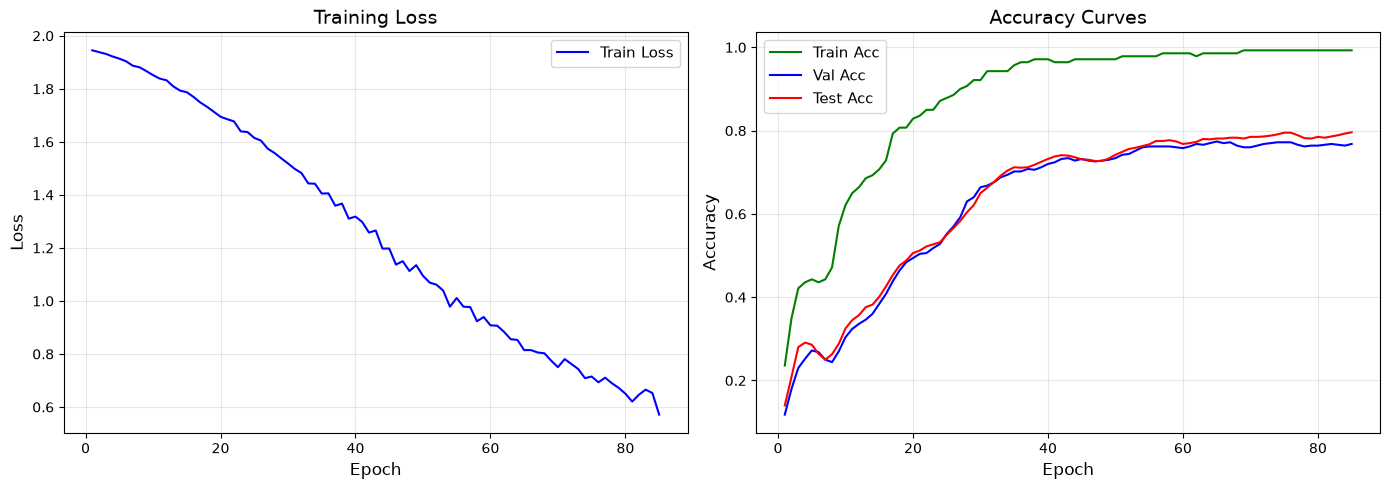

混淆矩阵已保存至: ./checkpoints\Cora_confusion_matrix.png


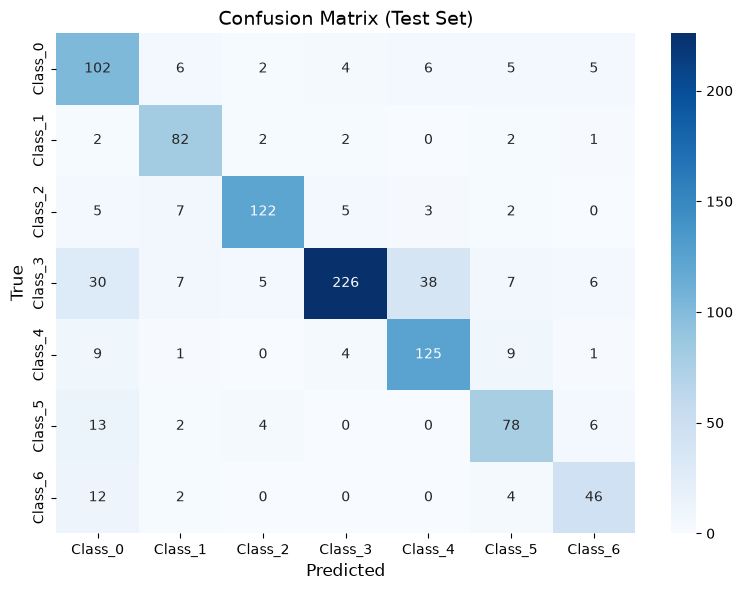

t-SNE 嵌入图已保存至: ./checkpoints\Cora_tsne_embeddings.png


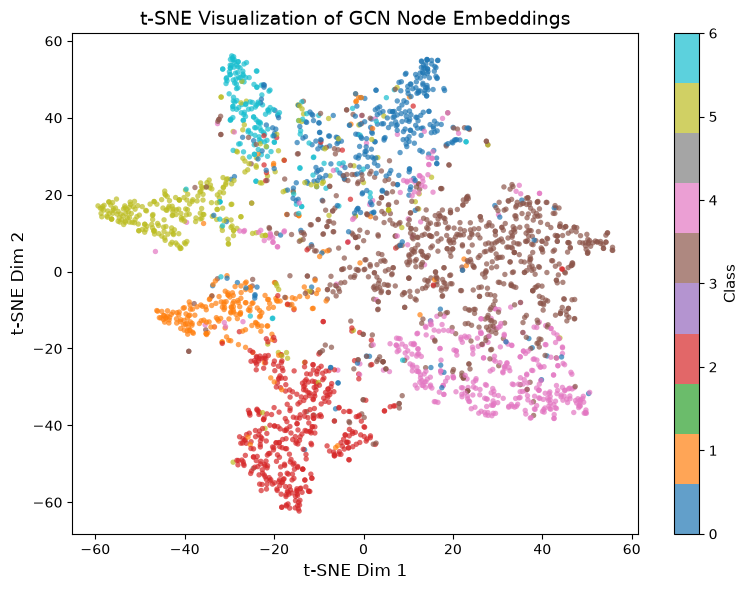


  GCN 训练与评估完成
  数据集       : Cora
  隐藏层维度   : 16
  Dropout      : 0.5
  学习率       : 0.01
  权重衰减     : 0.0005
  最终测试准确率: 0.7810
  最佳模型路径 : ./checkpoints\gcn_Cora_best.pth


In [1]:
"""
GCN 完整训练与评估脚本
数据集: Cora (论文引用网络节点分类)
框架: PyTorch Geometric (PyG)
"""

import os
import time
import torch
import torch.nn.functional as F
import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 0. 超参数配置
# ============================================================
DATASET_NAME = 'Cora'                          # 可选: Cora, Citeseer, Pubmed
DATA_ROOT = './data'
HIDDEN_CHANNELS = 16                           # 隐藏层维度
DROPOUT = 0.5                                  # Dropout 比率
LEARNING_RATE = 0.01                           # 学习率
WEIGHT_DECAY = 5e-4                            # L2 正则化
MAX_EPOCHS = 200                               # 最大训练轮数
PATIENCE = 20                                  # 早停耐心值
SAVE_DIR = './checkpoints'                     # 模型保存目录
SEED = 42                                      # 随机种子

# ============================================================
# 1. 设置随机种子（保证可复现）
# ============================================================
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ============================================================
# 2. 设备选择
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

# ============================================================
# 3. 数据加载与探索
# ============================================================
def load_data(dataset_name, data_root):
    """加载 Planetoid 数据集并进行特征归一化"""
    transform = T.NormalizeFeatures()  # 对节点特征做行归一化
    dataset = Planetoid(root=data_root, name=dataset_name, transform=transform)
    data = dataset[0].to(device)

    print(f'\n===== 数据集信息 =====')
    print(f'数据集名称     : {dataset_name}')
    print(f'节点数         : {data.num_nodes}')
    print(f'边数           : {data.num_edges}')
    print(f'特征维度       : {data.num_node_features}')
    print(f'类别数         : {dataset.num_classes}')
    print(f'训练节点数     : {data.train_mask.sum().item()}')
    print(f'验证节点数     : {data.val_mask.sum().item()}')
    print(f'测试节点数     : {data.test_mask.sum().item()}')
    print(f'========================\n')

    return dataset, data

dataset, data = load_data(DATASET_NAME, DATA_ROOT)

# ============================================================
# 4. 定义 GCN 模型
# ============================================================
class GCN(torch.nn.Module):
    """
    两层 GCN 模型
    结构: Input -> GCN(hidden) -> ReLU -> Dropout -> GCN(output)
    """
    def __init__(self, num_features, hidden_channels, num_classes, dropout=0.5):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # 第一层图卷积 + ReLU + Dropout
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        # 第二层图卷积（输出层，不加激活）
        x = self.conv2(x, edge_index)
        return x

model = GCN(
    num_features=dataset.num_features,
    hidden_channels=HIDDEN_CHANNELS,
    num_classes=dataset.num_classes,
    dropout=DROPOUT
).to(device)

print(f'模型结构:\n{model}\n')

# ============================================================
# 5. 优化器
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# ============================================================
# 6. 训练函数
# ============================================================
def train(model, data, optimizer):
    """执行一个 epoch 的训练，返回损失值"""
    model.train()
    optimizer.zero_grad()

    # 前向传播
    out = model(data.x, data.edge_index)

    # 仅在训练节点上计算交叉熵损失
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

    # 反向传播与参数更新
    loss.backward()
    optimizer.step()

    return loss.item()

# ============================================================
# 7. 评估函数
# ============================================================
@torch.no_grad()
def evaluate(model, data):
    """
    评估模型在训练集、验证集、测试集上的准确率
    返回: (train_acc, val_acc, test_acc)
    """
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)  # 取概率最大的类别作为预测

    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        correct = (pred[mask] == data.y[mask]).sum().item()
        total = mask.sum().item()
        accs.append(correct / total)

    return accs  # [train_acc, val_acc, test_acc]

# ============================================================
# 8. 训练循环（含早停机制）
# ============================================================
def train_loop(model, data, optimizer, max_epochs, patience):
    """
    完整训练循环，包含:
    - 每个 epoch 记录 loss 和各项准确率
    - 基于验证集准确率的早停机制
    - 自动保存最佳模型
    """
    os.makedirs(SAVE_DIR, exist_ok=True)
    best_model_path = os.path.join(SAVE_DIR, f'gcn_{DATASET_NAME}_best.pth')

    best_val_acc = 0.0
    patience_counter = 0
    train_losses = []
    train_accs = []
    val_accs = []
    test_accs = []

    print('开始训练...')
    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        # --- 训练 ---
        loss = train(model, data, optimizer)

        # --- 评估 ---
        train_acc, val_acc, test_acc = evaluate(model, data)

        # --- 记录 ---
        train_losses.append(loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        # --- 打印进度 ---
        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch [{epoch:3d}/{max_epochs}] '
                  f'Loss: {loss:.4f} | '
                  f'Train Acc: {train_acc:.4f} | '
                  f'Val Acc: {val_acc:.4f} | '
                  f'Test Acc: {test_acc:.4f}')

        # --- 早停检查 ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            # 保存最佳模型
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'test_acc': test_acc,
            }, best_model_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\n早停触发: 验证集准确率已连续 {patience} 轮未提升')
                print(f'最佳验证准确率: {best_val_acc:.4f} (Epoch {epoch - patience})')
                break

    elapsed = time.time() - start_time
    print(f'\n训练完成! 总耗时: {elapsed:.2f}s')

    # 加载最佳模型
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'已加载最佳模型 (Epoch {checkpoint["epoch"]}, '
          f'Val Acc: {checkpoint["val_acc"]:.4f}, '
          f'Test Acc: {checkpoint["test_acc"]:.4f})')

    return train_losses, train_accs, val_accs, test_accs

train_losses, train_accs, val_accs, test_accs = train_loop(
    model, data, optimizer, MAX_EPOCHS, PATIENCE
)

# ============================================================
# 9. 最终测试集评估
# ============================================================
print('\n===== 最终评估结果 =====')
final_train_acc, final_val_acc, final_test_acc = evaluate(model, data)
print(f'训练集准确率 : {final_train_acc:.4f}')
print(f'验证集准确率 : {final_val_acc:.4f}')
print(f'测试集准确率 : {final_test_acc:.4f}')
print(f'========================')

# ============================================================
# 10. 详细分类指标（Precision / Recall / F1）
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix

@torch.no_grad()
def detailed_evaluation(model, data):
    """输出测试集上的详细分类报告"""
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()

    # 获取类别名称（Cora 的类别）
    class_names = [f'Class_{i}' for i in range(dataset.num_classes)]

    print('\n===== 分类报告 (测试集) =====')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    print('===== 混淆矩阵 =====')
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    return y_true, y_pred

y_true, y_pred = detailed_evaluation(model, data)

# ============================================================
# 11. 可视化
# ============================================================
def plot_training_curves(train_losses, train_accs, val_accs, test_accs, save_dir):
    """绘制训练过程的损失和准确率曲线"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(train_losses) + 1)

    # 损失曲线
    axes[0].plot(epochs, train_losses, 'b-', linewidth=1.5, label='Train Loss')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss', fontsize=14)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # 准确率曲线
    axes[1].plot(epochs, train_accs, 'g-', linewidth=1.5, label='Train Acc')
    axes[1].plot(epochs, val_accs, 'b-', linewidth=1.5, label='Val Acc')
    axes[1].plot(epochs, test_accs, 'r-', linewidth=1.5, label='Test Acc')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Accuracy Curves', fontsize=14)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(save_dir, f'{DATASET_NAME}_training_curves.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'\n训练曲线已保存至: {save_path}')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, save_dir):
    """绘制混淆矩阵热力图"""
    import seaborn as sns

    cm = confusion_matrix(y_true, y_pred)
    class_names = [f'Class_{i}' for i in range(dataset.num_classes)]

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title('Confusion Matrix (Test Set)', fontsize=14)

    plt.tight_layout()
    save_path = os.path.join(save_dir, f'{DATASET_NAME}_confusion_matrix.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'混淆矩阵已保存至: {save_path}')
    plt.show()

plot_training_curves(train_losses, train_accs, val_accs, test_accs, SAVE_DIR)
plot_confusion_matrix(y_true, y_pred, SAVE_DIR)

# ============================================================
# 12. 节点嵌入 t-SNE 可视化
# ============================================================
def visualize_embeddings(model, data, save_dir):
    """使用 t-SNE 可视化 GCN 第一层输出的节点嵌入"""
    from sklearn.manifold import TSNE

    model.eval()
    with torch.no_grad():
        # 获取第一层 GCN 的输出作为节点嵌入
        out = model.conv1(data.x, data.edge_index)
        out = F.relu(out)
        embeddings = out.cpu().numpy()

    # t-SNE 降维到 2D
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    emb_2d = tsne.fit_transform(embeddings)

    # 绘图
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                         c=data.y.cpu().numpy(), cmap='tab10',
                         s=15, alpha=0.7, edgecolors='none')

    # 添加颜色条和图例
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Class', fontsize=11)
    ax.set_title('t-SNE Visualization of GCN Node Embeddings', fontsize=14)
    ax.set_xlabel('t-SNE Dim 1', fontsize=12)
    ax.set_ylabel('t-SNE Dim 2', fontsize=12)

    plt.tight_layout()
    save_path = os.path.join(save_dir, f'{DATASET_NAME}_tsne_embeddings.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f't-SNE 嵌入图已保存至: {save_path}')
    plt.show()

visualize_embeddings(model, data, SAVE_DIR)

# ============================================================
# 13. 汇总输出
# ============================================================
print('\n' + '=' * 50)
print(f'  GCN 训练与评估完成')
print(f'  数据集       : {DATASET_NAME}')
print(f'  隐藏层维度   : {HIDDEN_CHANNELS}')
print(f'  Dropout      : {DROPOUT}')
print(f'  学习率       : {LEARNING_RATE}')
print(f'  权重衰减     : {WEIGHT_DECAY}')
print(f'  最终测试准确率: {final_test_acc:.4f}')
print(f'  最佳模型路径 : {os.path.join(SAVE_DIR, f"gcn_{DATASET_NAME}_best.pth")}')
print('=' * 50)